In [3]:
# =============================================================================
# CÉLULA 1: INSTALAÇÃO DE BIBLIOTECAS
# =============================================================================
# ⏳ Espere essa célula terminar completamente antes de rodar a próxima!
# Quando aparecer "✅ Instalação concluída!", pode ir para a Célula 2.

!pip install pandas scikit-learn joblib yake sentence-transformers matplotlib seaborn numpy -q

print("✅ Instalação concluída!")
print("🔄 Agora vá para a Célula 2 (Imports)")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 360.5/360.5 kB 21.9 MB/s eta 0:00:00
✅ Instalação concluída!
🔄 Agora vá para a Célula 2 (Imports)


In [4]:
# =============================================================================
# CÉLULA 2: IMPORTS
# =============================================================================
import os
import re
import json
import joblib
import warnings
import numpy as np
import pandas as pd
from datetime import datetime

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score
)

import matplotlib.pyplot as plt
import seaborn as sns

# YAKE pode dar erro em algumas versões do Colab, então usamos try/except
try:
    import yake
    YAKE_DISPONIVEL = True
    print("✅ YAKE importado com sucesso!")
except ImportError:
    YAKE_DISPONIVEL = False
    print("⚠️  YAKE não disponível. Usaremos TF-IDF para keywords como fallback.")

from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")
print("✅ Todas as bibliotecas carregadas!")

✅ YAKE importado com sucesso!
✅ Todas as bibliotecas carregadas!


In [8]:
# =============================================================================
# CÉLULA 3: CARREGAR O DATASET
# =============================================================================
# Se você fez upload manual do CSV, coloque o nome exato do arquivo aqui:
NOME_ARQUIVO = "techtagger_dataset (1)"  # <-- Mude se o nome for diferente

# Verifica se existe, senão tenta achar qualquer CSV na pasta
import glob
csv_files = glob.glob("*.csv")

if not os.path.exists(NOME_ARQUIVO) and csv_files:
    NOME_ARQUIVO = csv_files[0]
    print(f"📁 Usando arquivo encontrado: {NOME_ARQUIVO}")
elif not os.path.exists(NOME_ARQUIVO):
    print("❌ CSV não encontrado. Faça upload do arquivo primeiro!")
    print("   Clique no ícone 📁 à esquerda → Upload")
    raise FileNotFoundError("CSV não encontrado")

df = pd.read_csv(NOME_ARQUIVO)

print(f"✅ Dataset carregado: {len(df)} linhas")
print(f"📊 Colunas: {list(df.columns)}")

# Se não tiver a coluna 'text', cria a partir de title + description
if "text" not in df.columns:
    print("📝 Criando coluna 'text' a partir de title + description...")
    df["text"] = df["title"].fillna("") + ". " + df["description"].fillna("")

# Garante que temos as colunas necessárias
if "category" not in df.columns:
    # Tenta achar uma coluna similar
    possiveis = [c for c in df.columns if any(x in c.lower() for x in ["cat", "label", "class", "tag"])]
    if possiveis:
        df = df.rename(columns={possiveis[0]: "category"})
        print(f"🔄 Coluna '{possiveis[0]}' renomeada para 'category'")
    else:
        raise ValueError("Coluna 'category' não encontrada no CSV!")

print(f"\n📊 Distribuição por categoria:")
print(df["category"].value_counts())

📁 Usando arquivo encontrado: techtagger_dataset (1).csv
✅ Dataset carregado: 388 linhas
📊 Colunas: ['title', 'text', 'category', 'content', 'word_count', 'char_count', 'content_clean']

📊 Distribuição por categoria:
category
Backend             55
Frontend            55
Cloud               55
Data Science        55
Mobile              42
Data Engineering    42
DevOps              42
Databases           42
Name: count, dtype: int64


In [9]:
# =============================================================================
# CÉLULA 4: LIMPEZA DE TEXTO
# =============================================================================
def limpar_texto(texto):
    """Limpa o texto para o modelo."""
    if not isinstance(texto, str):
        return ""
    texto = texto.lower()
    texto = re.sub(r'http\S+|www\.\S+', '', texto)
    texto = re.sub(r'[^a-z0-9\s\.\-\+#]', ' ', texto)
    texto = re.sub(r'\s+', ' ', texto).strip()
    return texto

df["text_clean"] = df["text"].apply(limpar_texto)

# Remove textos muito curtos
antes = len(df)
df = df[df["text_clean"].str.len() >= 20].reset_index(drop=True)
print(f"🧹 Removidos {antes - len(df)} artigos muito curtos")
print(f"✅ Dataset final: {len(df)} artigos")

# Mostra exemplo
print(f"\n📝 Exemplo de texto limpo:")
print(df["text_clean"].iloc[0][:200] + "...")

🧹 Removidos 0 artigos muito curtos
✅ Dataset final: 388 artigos

📝 Exemplo de texto limpo:
in this content we present the basic concepts for creating rest apis using java and spring boot. controllers services and dependency injection....


In [10]:
# =============================================================================
# CÉLULA 5: SPLIT DOS DADOS
# =============================================================================
X = df["text_clean"].values
y = df["category"].values

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y  # mantém proporção das categorias
)

print(f"📊 Treino: {len(X_train)} amostras")
print(f"📊 Teste:  {len(X_test)} amostras")
print(f"🏷️  Categorias: {len(np.unique(y))}")

📊 Treino: 310 amostras
📊 Teste:  78 amostras
🏷️  Categorias: 8


In [11]:
# =============================================================================
# CÉLULA 6: TREINAMENTO DO CLASSIFICADOR
# =============================================================================
pipeline = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1, 2),      # unigramas + bigramas
        min_df=2,                # ignora termos muito raros
        max_df=0.9,              # ignora termos muito comuns
        sublinear_tf=True,
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        C=1.0,
        class_weight="balanced",  # ajuda com categorias desbalanceadas
        random_state=42,
        n_jobs=-1
    ))
])

print("🏋️ Treinando modelo... (pode levar 10-30 segundos)")
pipeline.fit(X_train, y_train)
print("✅ Modelo treinado com sucesso!")

🏋️ Treinando modelo... (pode levar 10-30 segundos)
✅ Modelo treinado com sucesso!


🎯 Accuracy: 0.7564
🎯 F1-Score (weighted): 0.7614

📋 Relatório detalhado:

                  precision    recall  f1-score   support

         Backend       1.00      0.73      0.84        11
           Cloud       1.00      0.64      0.78        11
Data Engineering       0.58      0.78      0.67         9
    Data Science       0.69      0.82      0.75        11
       Databases       0.75      0.75      0.75         8
          DevOps       0.58      0.78      0.67         9
        Frontend       0.77      0.91      0.83        11
          Mobile       1.00      0.62      0.77         8

        accuracy                           0.76        78
       macro avg       0.80      0.75      0.76        78
    weighted avg       0.80      0.76      0.76        78



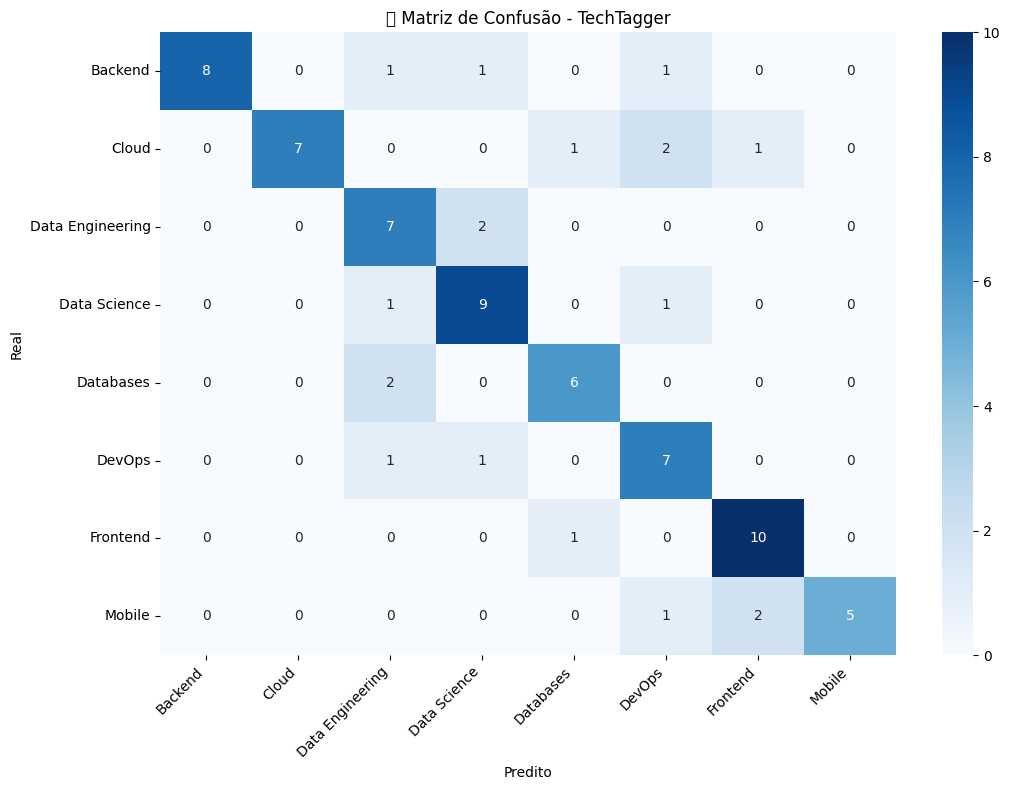


🔄 Validando com 5-fold cross-validation...
📊 F1 médio (CV): 0.6842 ± 0.0691


In [12]:
# =============================================================================
# CÉLULA 7: AVALIAÇÃO DO MODELO
# =============================================================================
y_pred = pipeline.predict(X_test)

acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="weighted")

print(f"🎯 Accuracy: {acc:.4f}")
print(f"🎯 F1-Score (weighted): {f1:.4f}")
print(f"\n📋 Relatório detalhado:\n")
print(classification_report(y_test, y_pred))

# Matriz de confusão
labels = sorted(np.unique(y))
cm = confusion_matrix(y_test, y_pred, labels=labels)

plt.figure(figsize=(11, 8))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("🔮 Matriz de Confusão - TechTagger")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=100, bbox_inches="tight")
plt.show()

# Validação cruzada (opcional, pode comentar se estiver lento)
print("\n🔄 Validando com 5-fold cross-validation...")
scores = cross_val_score(pipeline, X, y, cv=5, scoring="f1_weighted", n_jobs=-1)
print(f"📊 F1 médio (CV): {scores.mean():.4f} ± {scores.std():.4f}")

In [15]:
# =============================================================================
# CÉLULA 8: TESTES MANUAIS
# =============================================================================
def classificar(texto, top_n=3):
    """Classifica um texto e retorna top-N categorias."""
    texto_limpo = limpar_texto(texto)
    probs = pipeline.predict_proba([texto_limpo])[0]
    classes = pipeline.classes_
    top_idx = np.argsort(probs)[::-1][:top_n]
    return {
        "categoria_principal": str(classes[top_idx[0]]),
        "probabilidade": round(float(probs[top_idx[0]]), 4),
        "top_categorias": [
            {"nome": str(classes[i]), "score": round(float(probs[i]), 4)}
            for i in top_idx
        ]
    }

# Testes rápidos
exemplos = [
    "Building REST APIs with Spring Boot and Java for microservices",
    "React hooks tutorial: useState and useEffect for beginners",
    "Docker containers and Kubernetes orchestration for production",
    "Training neural networks with PyTorch for image classification",
    "SQL query optimization in PostgreSQL databases"
]

print("🧪 Testando classificador:\n")
for ex in exemplos:
    r = classificar(ex)
    print(f"📝 {ex[:60]}...")
    print(f"   → {r['categoria_principal']} ({r['probabilidade']:.2%})")
    print()

🧪 Testando classificador:

📝 Building REST APIs with Spring Boot and Java for microservic...
   → Backend (60.17%)

📝 React hooks tutorial: useState and useEffect for beginners...
   → Frontend (39.79%)

📝 Docker containers and Kubernetes orchestration for productio...
   → DevOps (20.35%)

📝 Training neural networks with PyTorch for image classificati...
   → Data Science (13.63%)

📝 SQL query optimization in PostgreSQL databases...
   → Databases (32.35%)



In [16]:
# =============================================================================
# CÉLULA 9: GERAR EMBEDDINGS (demora 1-2 minutos)
# =============================================================================
print("🧠 Carregando modelo de embeddings...")
model_emb = SentenceTransformer("all-MiniLM-L6-v2")

print("🧠 Gerando embeddings para todos os artigos...")
embeddings = model_emb.encode(
    df["text_clean"].tolist(),
    show_progress_bar=True,
    batch_size=32  # menor batch para não estourar memória
)

print(f"\n✅ Embeddings gerados! Shape: {embeddings.shape}")

🧠 Carregando modelo de embeddings...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

🧠 Gerando embeddings para todos os artigos...


Batches:   0%|          | 0/13 [00:00<?, ?it/s]


✅ Embeddings gerados! Shape: (388, 384)


In [17]:
# =============================================================================
# CÉLULA 10: KEYWORDS (YAKE ou Fallback)
# =============================================================================
if YAKE_DISPONIVEL:
    kw_extractor = yake.KeywordExtractor(lan="en", n=2, dedupLim=0.7, top=5)
    def extrair_keywords(texto, top=5):
        keywords = kw_extractor.extract_keywords(texto)
        return [kw for kw, score in keywords[:top]]
    print("✅ Usando YAKE para extração de keywords")
else:
    # Fallback: usa TF-IDF do próprio pipeline
    print("⚠️  Usando TF-IDF como fallback para keywords")
    def extrair_keywords(texto, top=5):
        # Pega as features mais importantes do texto
        texto_limpo = limpar_texto(texto)
        tfidf_matrix = pipeline.named_steps['tfidf'].transform([texto_limpo])
        feature_names = pipeline.named_steps['tfidf'].get_feature_names_out()
        scores = tfidf_matrix.toarray()[0]
        top_idx = np.argsort(scores)[::-1][:top]
        return [feature_names[i] for i in top_idx if scores[i] > 0]

# Teste
for ex in exemplos[:3]:
    kws = extrair_keywords(ex)
    print(f"📝 {ex[:50]}...")
    print(f"   🔑 Keywords: {kws}")

✅ Usando YAKE para extração de keywords
📝 Building REST APIs with Spring Boot and Java for m...
   🔑 Keywords: ['Spring Boot', 'Building REST', 'REST APIs', 'REST', 'Spring']
📝 React hooks tutorial: useState and useEffect for b...
   🔑 Keywords: ['React hooks', 'hooks tutorial', 'React', 'tutorial', 'useState']
📝 Docker containers and Kubernetes orchestration for...
   🔑 Keywords: ['Kubernetes orchestration', 'Docker containers', 'Kubernetes', 'Docker', 'production']


In [18]:
# =============================================================================
# CÉLULA 11: SERIALIZAÇÃO (OS 4 ARQUIVOS OFICIAIS)
# =============================================================================
os.makedirs("models", exist_ok=True)

# 1. Classificador
joblib.dump(pipeline, "models/classifier.pkl")
print("✅ 1/4 - models/classifier.pkl")

# 2. Embeddings
np.save("models/embeddings.npy", embeddings)
print("✅ 2/4 - models/embeddings.npy")

# 3. Metadata (info dos artigos para recomendação)
cols_salvar = ["title", "category"]
if "url" in df.columns:
    cols_salvar.append("url")
if "description" in df.columns:
    cols_salvar.append("description")

metadata = df[cols_salvar].copy()
if "url" not in df.columns:
    metadata["url"] = ""

metadata.to_csv("models/metadata.csv", index=False)
print("✅ 3/4 - models/metadata.csv")

# 4. Info do modelo
info = {
    "model_version": "1.0.0",
    "trained_at": datetime.now().isoformat(),
    "n_samples": int(len(df)),
    "n_categories": int(len(np.unique(y))),
    "categories": sorted(np.unique(y).tolist()),
    "accuracy_test": round(float(acc), 4),
    "f1_weighted_test": round(float(f1), 4),
    "embedding_model": "all-MiniLM-L6-v2",
    "embedding_dim": int(embeddings.shape[1])
}

with open("models/model_info.json", "w") as f:
    json.dump(info, f, indent=2)
print("✅ 4/4 - models/model_info.json")

# Resumo
print("\n" + "="*50)
print("🎉 ARQUIVOS GERADOS COM SUCESSO!")
print("="*50)
for f in os.listdir("models"):
    size = os.path.getsize(f"models/{f}") / 1024
    print(f"  📄 {f:<25s} ({size:>8.1f} KB)")

✅ 1/4 - models/classifier.pkl
✅ 2/4 - models/embeddings.npy
✅ 3/4 - models/metadata.csv
✅ 4/4 - models/model_info.json

🎉 ARQUIVOS GERADOS COM SUCESSO!
  📄 model_info.json           (     0.4 KB)
  📄 embeddings.npy            (   582.1 KB)
  📄 classifier.pkl            (    73.6 KB)
  📄 metadata.csv              (    14.4 KB)


In [19]:
# =============================================================================
# CÉLULA 12: BAIXAR OS ARQUIVOS (Google Colab)
# =============================================================================
from google.colab import files
import shutil

# Compacta
shutil.make_archive("models", "zip", "models")

# Baixa
files.download("models.zip")
print("⬇️  Download do models.zip iniciado!")
print("💡 Descompacte e coloque os 4 arquivos na pasta 'models/' do seu projeto API")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  Download do models.zip iniciado!
💡 Descompacte e coloque os 4 arquivos na pasta 'models/' do seu projeto API
